# HBR ZINB likelihood

The topic of this notebook:

1. **HBR likelihoods: $F$ and $\Phi^{-1}$** — the two functions that do all the work for the HBR likelihoods, and how they
   relate to `cdf` and `ppf` in code.
2. **The ZINB distribution** — what "zero-inflated" means and where $\psi$ sits.
3. **The discreteness problem** — why the recipe from step 1 breaks for counts.
4. **Randomized quantile residuals** — the fix, which is what PCNtoolkit implements.

Every section has a plot, and most have a parameter you can change and re-run.



In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import nbinom, norm

# --- plotting style (one place, so every figure below matches) ---------------
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Categorical colors, used consistently throughout:
C_DATA = "#2a78d6"   # blue   - the data / the distribution
C_MAP  = "#eb6834"   # orange - the mapping (arrows, U values)
C_NB   = "#1baf7a"   # aqua   - the negative binomial component
C_ZERO = "#e34948"   # red    - the structural-zero component
C_MUTE = "#898781"   # gray   - reference lines, annotation

rng = np.random.default_rng(0)

---
## 1. HBR likelihoods: $F$ and $\Phi^{-1}$

### $F$ — the cumulative distribution function (CDF)

$F(y)$ answers one question:

$$F(y) = P(Y \le y) = \text{"what fraction of the population scores at or below } y \text{?"}$$

It always starts at 0, ends at 1, and never decreases. In code it is `.cdf(y)`.

### $\Phi$ and $\Phi^{-1}$ — the normal CDF and its inverse (=PPF)

$\Phi$ is just $F$ for the *standard normal* distribution — the bell curve with mean 0
and standard deviation 1. The capital Greek phi is a convention meaning "the CDF of
the normal, specifically."

$\Phi^{-1}$ is its **inverse**, called the **quantile function** or **percent-point
function**. It runs the question backwards:

$$\Phi(z) = p \quad\Longleftrightarrow\quad \Phi^{-1}(p) = z$$

- $\Phi(1.96) = 0.975$ — "a z-score of 1.96 puts you above 97.5% of people"
- $\Phi^{-1}(0.975) = 1.96$ — "to be above 97.5% of people you need z = 1.96"

In code $\Phi$ is `norm.cdf` and $\Phi^{-1}$ is `norm.ppf` (**p**ercent **p**oint
**f**unction). This is exactly what `BetaLikelihood` does in PCNtoolkit — `stats.beta.cdf` then
`stats.norm.ppf`. **`ppf` is always the inverse of `cdf`**

### Y->Z and Z->Y

Put them together and you get the standard way to build a z-score for **any**
distribution. This is the Y->Z mapping, the so called forward() function:

$$z = \Phi^{-1}\big(F(y)\big)$$

Read it left to right:

1. $F(y)$ — turn the observation into a percentile. *"You're at the 84th percentile."*
2. $\Phi^{-1}(\cdot)$ — turn that percentile into the equivalent z-score. *"That's z = 1."*

Going backwards is the same recipe reversed — this is how **centiles** are computed:

$$y = F^{-1}\big(\Phi(z)\big)$$

### Probability integral transform

The reason this works is the **probability integral transform**: if $Y$ really comes
from the distribution with CDF $F$, then $F(Y)$ is uniform** on $[0,1]$. And pushing a
uniform through $\Phi^{-1}$ produces exactly a standard normal. So $z \sim N(0,1)$ —
which is what a z-score is supposed to be.

> ** The intuition for F(Y) being uniform
> F(y) isn't a value, it's a rank: "what fraction of the population is at or below you." Ask that question of everyone in the population and the answers spread out evenly by construction:
>
> Exactly 10% of people are below the 10th percentile.
> Exactly 10% of people sit between the 10th and the 20th percentile.
> …and so on, for every 10% slice.


Let's watch the transform actually happen on a skewed distribution.

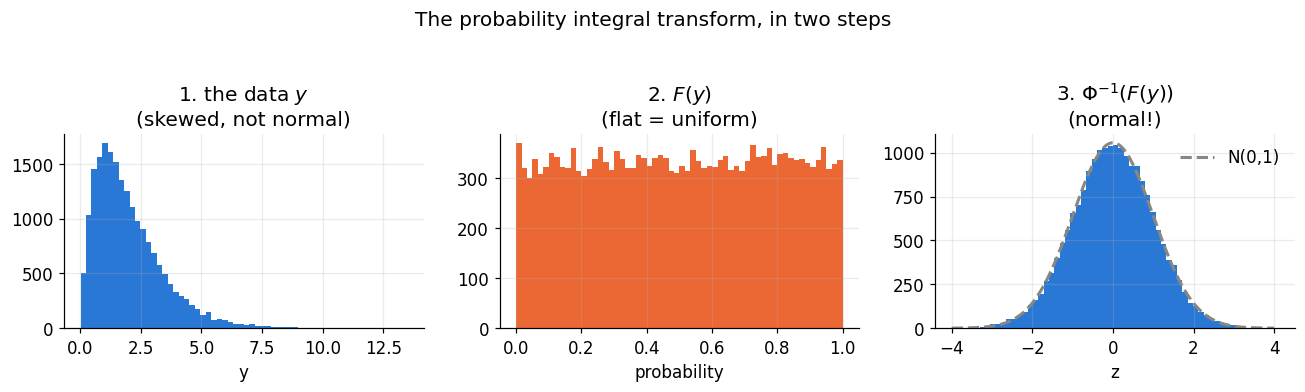

z mean = +0.005  (target 0)
z std  = 1.004  (target 1)


In [15]:
from scipy.stats import gamma

shape = 2.0
y_samp = gamma.rvs(shape, size=20000, random_state=rng)

u_samp = gamma.cdf(y_samp, shape)     # step 1: F(y)   -> uniform
z_samp = norm.ppf(u_samp)             # step 2: Phi^-1 -> normal

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].hist(y_samp, bins=60, color=C_DATA, edgecolor="none")
axes[0].set(title="1. the data $y$\n(skewed, not normal)", xlabel="y")

axes[1].hist(u_samp, bins=60, color=C_MAP, edgecolor="none")
axes[1].set(title="2. $F(y)$\n(flat = uniform)", xlabel="probability")

axes[2].hist(z_samp, bins=60, color=C_DATA, edgecolor="none")
zz = np.linspace(-4, 4, 200)
axes[2].plot(zz, norm.pdf(zz) * len(z_samp) * (z_samp.max() - z_samp.min()) / 60,
             color=C_MUTE, lw=2, ls="--", label="N(0,1)")
axes[2].legend(frameon=False)
axes[2].set(title=r"3. $\Phi^{-1}(F(y))$" + "\n(normal!)", xlabel="z")

fig.suptitle("The probability integral transform, in two steps", y=1.04)
plt.tight_layout()
plt.show()

print(f"z mean = {z_samp.mean():+.3f}  (target 0)")
print(f"z std  = {z_samp.std():.3f}  (target 1)")

---
## 2. What ZINB is

**ZINB = Zero-Inflated Negative Binomial.** It is a mixture of two things:

$$
Y = \begin{cases}
0 & \text{with probability } 1-\psi \quad \text{(a \textbf{structural zero})}\\[4pt]
\text{NegBinom}(\mu, \alpha) & \text{with probability } \psi
\end{cases}
$$

The **negative binomial** is a count distribution with mean $\mu$ and a shape
parameter $\alpha$ controlling how spread out it is. Crucially it can produce zeros
*on its own*.

A **structural zero** is different: it's someone the count doesn't apply to at all.
Think of a symptom count — some people have zero because they were measured and
scored none (a negative binomial zero), and others have zero because they don't have
the condition at all (a structural zero).

> ### ⚠️ The $\psi$
>
> In **PyMC** (which PCNtoolkit uses), the docs define `psi` as the
> *"expected proportion of NegativeBinomial draws"*. So:
>
> $$\psi = P(\text{drawn from the NB component}), \qquad 1-\psi = P(\text{structural zero})$$

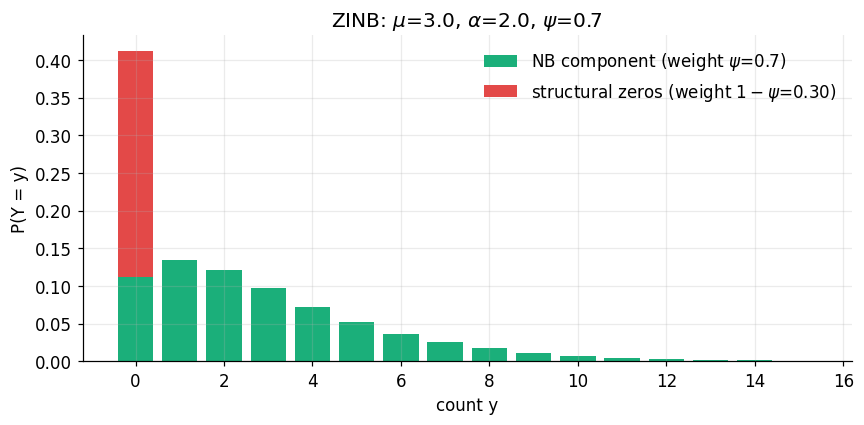

P(Y=0) total   = 0.4120
  of which structural = 0.3000, from the NB itself = 0.1120
mean = psi*mu  = 2.100


In [16]:
def zinb_pmf(y, mu, alpha, psi):
    '''P(Y = y). The structural zeros add mass only at y = 0.'''
    n, p = alpha, alpha / (alpha + mu)
    out = psi * nbinom.pmf(y, n, p)
    return np.where(y == 0, (1 - psi) + out, out)


mu, alpha, psi = 3.0, 2.0, 0.7     # <-- CHANGE THESE AND RE-RUN
ys = np.arange(0, 16)

n, p = alpha, alpha / (alpha + mu)
nb_part = psi * nbinom.pmf(ys, n, p)          # the NB component, weighted
zi_part = np.where(ys == 0, 1 - psi, 0.0)     # the structural zeros

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ys, nb_part, color=C_NB, label=fr"NB component (weight $\psi$={psi})")
ax.bar(ys, zi_part, bottom=nb_part, color=C_ZERO,
       label=fr"structural zeros (weight $1-\psi$={1-psi:.2f})")
ax.set(xlabel="count y", ylabel="P(Y = y)",
       title=f"ZINB: $\\mu$={mu}, $\\alpha$={alpha}, $\\psi$={psi}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"P(Y=0) total   = {zinb_pmf(0, mu, alpha, psi):.4f}")
print(f"  of which structural = {1-psi:.4f}, from the NB itself = {psi*nbinom.pmf(0,n,p):.4f}")
print(f"mean = psi*mu  = {psi*mu:.3f}")

The red block is the extra spike at zero that makes this "zero-inflated". Try
$\psi = 0.95$ (almost no structural zeros — nearly a plain negative binomial) and
$\psi = 0.3$ (mostly structural zeros).


### Watch the centiles respond to the ZINB parameters

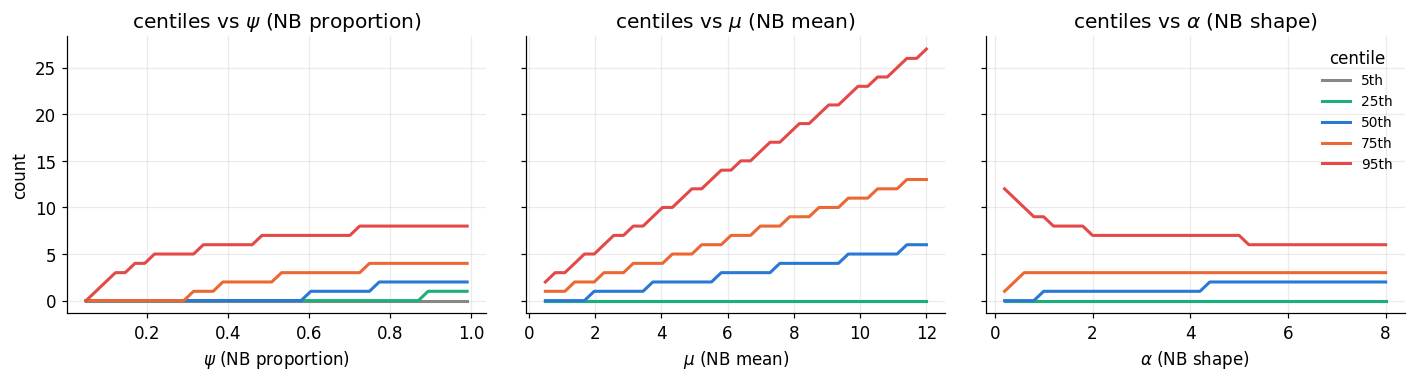

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
cent = np.array([0.05, 0.25, 0.5, 0.75, 0.95])

sweeps = [("$\\psi$ (NB proportion)", "psi", np.linspace(0.05, 0.99, 40)),
          ("$\\mu$ (NB mean)",        "mu",  np.linspace(0.5, 12, 40)),
          ("$\\alpha$ (NB shape)",    "alpha", np.linspace(0.2, 8, 40))]

for ax, (label, which, values) in zip(axes, sweeps):
    curves = {c: [] for c in cent}
    for v in values:
        kw = {"mu": mu, "alpha": alpha, "psi": psi} | {which: v}
        for c in cent:
            curves[c].append(zinb_backward(np.array([norm.ppf(c)]), **kw)[0])
    for c, col in zip(cent, [C_MUTE, C_NB, C_DATA, C_MAP, C_ZERO]):
        ax.plot(values, curves[c], color=col, lw=2, label=f"{int(c*100)}th")
    ax.set(xlabel=label, title=f"centiles vs {label}")
axes[0].set_ylabel("count")
axes[2].legend(frameon=False, title="centile", fontsize=9)
plt.tight_layout()
plt.show()

Things worth noticing (and worth predicting *before* you look):

- As $\psi \to 0$ almost everything is a structural zero, so every centile collapses to 0.
- $\mu$ pushes the upper centiles up, but the low centiles stay pinned at 0 while the
  structural zeros still dominate the bottom of the distribution.
- Small $\alpha$ means a heavier tail, so the 95th centile rises sharply as
  $\alpha \to 0$ even though $\mu$ is unchanged.

Centiles sitting at exactly 0 is **correct**, not a bug — if more than 25% of the
population scores zero, the 25th centile genuinely *is* zero.

### The CDF of the mixture

To use our recipe we need $F$. For a mixture, the CDF is the **weighted sum** of the
two components' CDFs. The structural-zero component is a point mass at 0, so its CDF
is 0 below zero and 1 from zero onward:

$$\boxed{F(y) = (1-\psi) + \psi \cdot F_{\text{NB}}(y) \quad \text{for } y \ge 0}$$

and $F(y) = 0$ for $y < 0$.

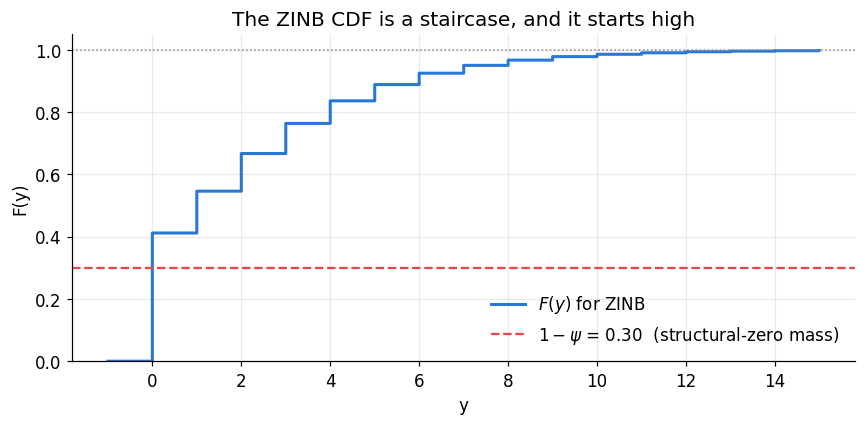

F(0) = 0.4120
F(1) = 0.5464
F(2) = 0.6674
F(3) = 0.7641
F(4) = 0.8367


In [18]:
def zinb_cdf(y, mu, alpha, psi):
    '''F(y) = (1-psi) + psi * F_NB(y).  This is THE formula -- everything else follows.'''
    n, p = alpha, alpha / (alpha + mu)
    return np.where(y < 0, 0.0, (1 - psi) + psi * nbinom.cdf(y, n, p))


fig, ax = plt.subplots(figsize=(8, 4))
grid = np.linspace(-1, 15, 2000)
ax.step(grid, zinb_cdf(np.floor(grid), mu, alpha, psi), where="post",
        color=C_DATA, lw=2, label=r"$F(y)$ for ZINB")
ax.axhline(1 - psi, color=C_ZERO, ls="--", lw=1.5,
           label=fr"$1-\psi$ = {1-psi:.2f}  (structural-zero mass)")
ax.axhline(1.0, color=C_MUTE, ls=":", lw=1)
ax.set(xlabel="y", ylabel="F(y)", ylim=(0, 1.05),
       title="The ZINB CDF is a staircase, and it starts high")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

for yv in range(5):
    print(f"F({yv}) = {zinb_cdf(yv, mu, alpha, psi):.4f}")

---
## 3. The problem: a staircase has gaps

Now try the recipe $z = \Phi^{-1}(F(y))$ on counts and watch it fail.

For continuous data, $F$ is a smooth curve — every $y$ maps to its own distinct
probability, so every $y$ gets its own distinct $z$. For counts, $F$ is a **staircase**.
It jumps from $F(0)$ straight to $F(1)$, taking **no values in between**.

So *every* person with $y=0$ receives the identical z-score, every person with $y=1$
receives another identical z-score, and so on. The z-scores pile up on a handful of
spikes instead of spreading into a bell curve.

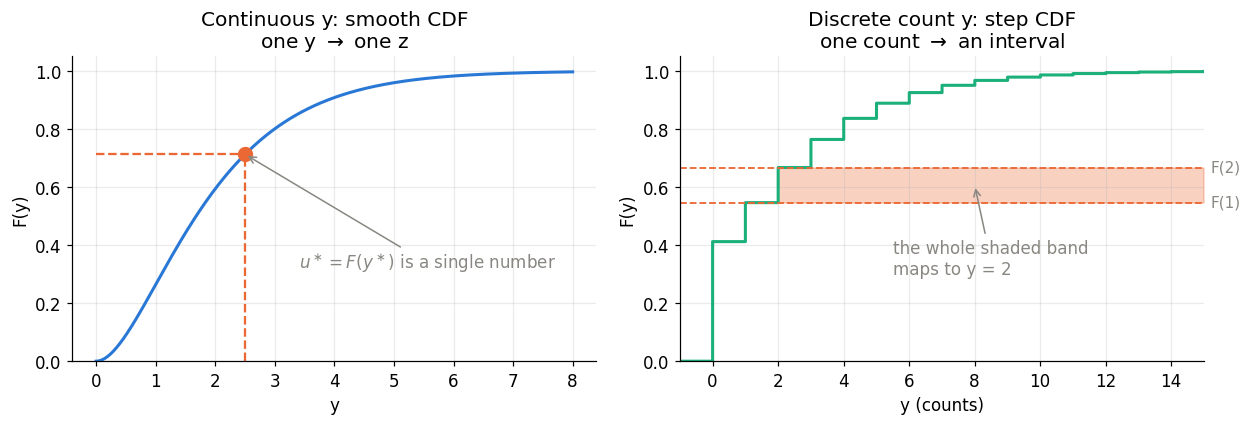

Every y=2 would get z = Phi^-1(0.6674) = +0.4326 -- identical for everyone.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

# --- left: continuous, one y -> one z --------------------------------------
yy = np.linspace(0, 8, 400)
axes[0].plot(yy, gamma.cdf(yy, 2.0), color=C_DATA, lw=2)
y_star = 2.5
u_star = gamma.cdf(y_star, 2.0)
axes[0].plot([y_star, y_star], [0, u_star], color=C_MAP, ls="--", lw=1.5)
axes[0].plot([0, y_star], [u_star, u_star], color=C_MAP, ls="--", lw=1.5)
axes[0].plot([y_star], [u_star], "o", color=C_MAP, ms=9)
axes[0].annotate(r"$u^\ast = F(y^\ast)$ is a single number",
                 xy=(y_star, u_star), xytext=(3.4, 0.32), color=C_MUTE,
                 arrowprops=dict(arrowstyle="->", color=C_MUTE))
axes[0].set(title="Continuous y: smooth CDF\none y $\\to$ one z",
            xlabel="y", ylabel="F(y)", ylim=(0, 1.05))

# --- right: discrete, one count -> an interval ------------------------------
axes[1].step(grid, zinb_cdf(np.floor(grid), mu, alpha, psi), where="post",
             color=C_NB, lw=2)
F1, F2 = zinb_cdf(1, mu, alpha, psi), zinb_cdf(2, mu, alpha, psi)
axes[1].fill_between([2, 15], F1, F2, color=C_MAP, alpha=0.30)
for lvl, lab in [(F1, "F(1)"), (F2, "F(2)")]:
    axes[1].axhline(lvl, color=C_MAP, ls="--", lw=1.2)
    axes[1].text(15.2, lvl, lab, va="center", color=C_MUTE, fontsize=10)
axes[1].annotate("the whole shaded band\nmaps to y = 2",
                 xy=(8, (F1 + F2) / 2), xytext=(5.5, 0.30), color=C_MUTE,
                 arrowprops=dict(arrowstyle="->", color=C_MUTE))
axes[1].set(title="Discrete count y: step CDF\none count $\\to$ an interval",
            xlabel="y (counts)", ylabel="F(y)", ylim=(0, 1.05), xlim=(-1, 15))

plt.tight_layout()
plt.show()

print(f"Every y=2 would get z = Phi^-1({F2:.4f}) = {norm.ppf(F2):+.4f} -- identical for everyone.")

Here is what that does to the z-scores if we apply the naive recipe to real data.

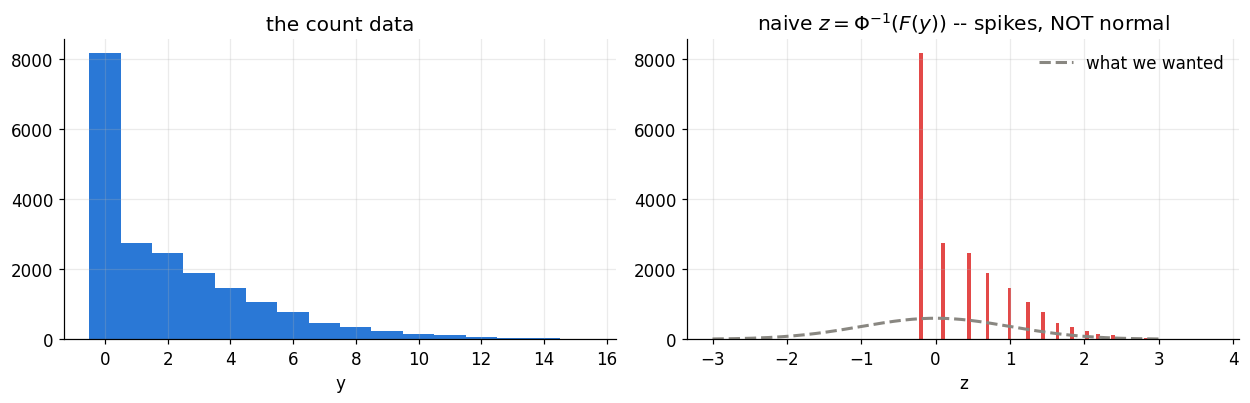

number of distinct z values: 21  <- should be ~20000


In [20]:
def zinb_rvs(size, mu, alpha, psi, rng):
    n, p = alpha, alpha / (alpha + mu)
    is_nb = rng.random(size) < psi
    return np.where(is_nb, nbinom.rvs(n, p, size=size, random_state=rng), 0)


y_counts = zinb_rvs(20000, mu, alpha, psi, rng)
z_naive = norm.ppf(np.clip(zinb_cdf(y_counts, mu, alpha, psi), 1e-12, 1 - 1e-12))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].hist(y_counts, bins=np.arange(-0.5, 16), color=C_DATA, edgecolor="none")
axes[0].set(title="the count data", xlabel="y")

axes[1].hist(z_naive, bins=80, color=C_ZERO, edgecolor="none")
axes[1].set(title="naive $z=\\Phi^{-1}(F(y))$ -- spikes, NOT normal", xlabel="z")
zz = np.linspace(-3, 3, 200)
axes[1].plot(zz, norm.pdf(zz) * len(z_naive) * 6 / 80, color=C_MUTE, lw=2, ls="--",
             label="what we wanted")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"number of distinct z values: {len(np.unique(z_naive))}  <- should be ~20000")

Those spikes are useless as z-scores: you cannot compare two people who both scored 0,
and a QQ plot would be a staircase.

Note this problem is caused by **discreteness alone** — plain Poisson or negative
binomial data has it too. Zero inflation just makes the biggest step (= the step from 0 to 1) even bigger.

---
## 4. The fix: randomized quantile residuals

The insight: a count $y$ doesn't correspond to a single probability, it corresponds to
the **interval the staircase skipped over**, namely $\big(F(y-1),\, F(y)\big]$.

So instead of mapping $y$ to one point, draw a value **uniformly from its interval**:

$$U \sim \text{Uniform}\big(F(y-1),\, F(y)\big), \qquad z = \Phi^{-1}(U)$$

and $z$ ends up to be normal: $N(0,1)$.

This is a standard published technique (Dunn & Smyth, 1996):

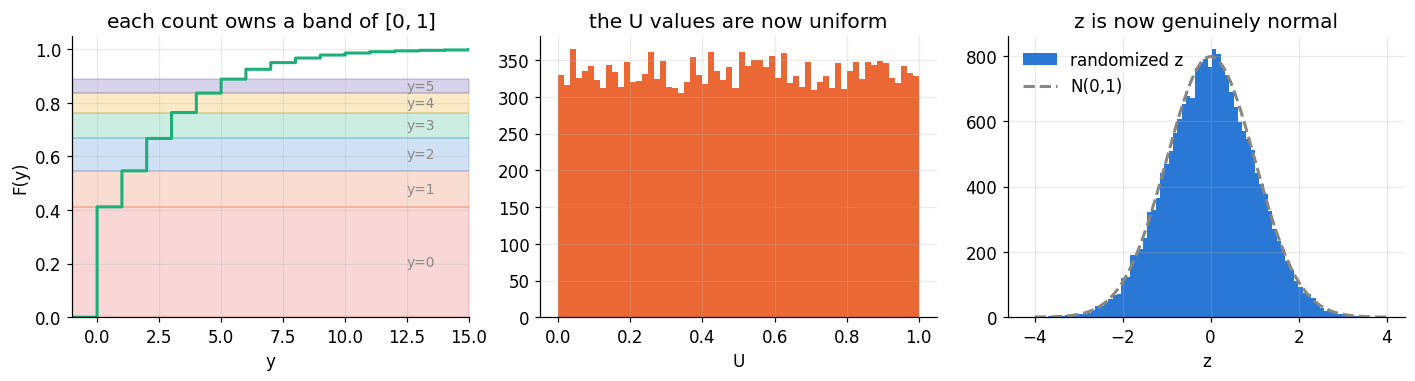

z mean = +0.0015   z std = 0.9986
KS test against N(0,1): p = 0.782  (want > 0.05)


In [21]:
def zinb_forward(y, mu, alpha, psi, rng):
    '''Counts -> z. Stochastic: draws uniformly inside each count CDF interval.'''
    lo = zinb_cdf(y - 1, mu, alpha, psi)     # F(y-1); note F(-1) = 0 for y = 0
    hi = zinb_cdf(y,     mu, alpha, psi)     # F(y)
    u = rng.uniform(lo, hi)
    eps = np.finfo(float).eps
    return norm.ppf(np.clip(u, eps, 1 - eps))


z_rqr = zinb_forward(y_counts, mu, alpha, psi, rng)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# where each count lands in [0,1]
axes[0].step(grid, zinb_cdf(np.floor(grid), mu, alpha, psi), where="post",
             color=C_NB, lw=2)
for k in range(0, 6):
    lo, hi = zinb_cdf(k - 1, mu, alpha, psi), zinb_cdf(k, mu, alpha, psi)
    axes[0].fill_between([-1, 15], lo, hi, alpha=0.22,
                         color=[C_ZERO, C_MAP, C_DATA, C_NB, "#eda100", "#4a3aa7"][k])
    axes[0].text(12.5, (lo + hi) / 2, f"y={k}", va="center", fontsize=9, color=C_MUTE)
axes[0].set(title="each count owns a band of $[0,1]$", xlabel="y", ylabel="F(y)",
            ylim=(0, 1.05), xlim=(-1, 15))

axes[1].hist(norm.cdf(z_rqr), bins=60, color=C_MAP, edgecolor="none")
axes[1].set(title="the U values are now uniform", xlabel="U")

axes[2].hist(z_rqr, bins=80, color=C_DATA, edgecolor="none", label="randomized z")
zz = np.linspace(-4, 4, 200)
axes[2].plot(zz, norm.pdf(zz) * len(z_rqr) * 8 / 80, color=C_MUTE, lw=2, ls="--",
             label="N(0,1)")
axes[2].legend(frameon=False)
axes[2].set(title="z is now genuinely normal", xlabel="z")

plt.tight_layout()
plt.show()

from scipy.stats import kstest
print(f"z mean = {z_rqr.mean():+.4f}   z std = {z_rqr.std():.4f}")
print(f"KS test against N(0,1): p = {kstest(z_rqr, 'norm').pvalue:.3f}  (want > 0.05)")

And a QQ plot now sits on the diagonal:

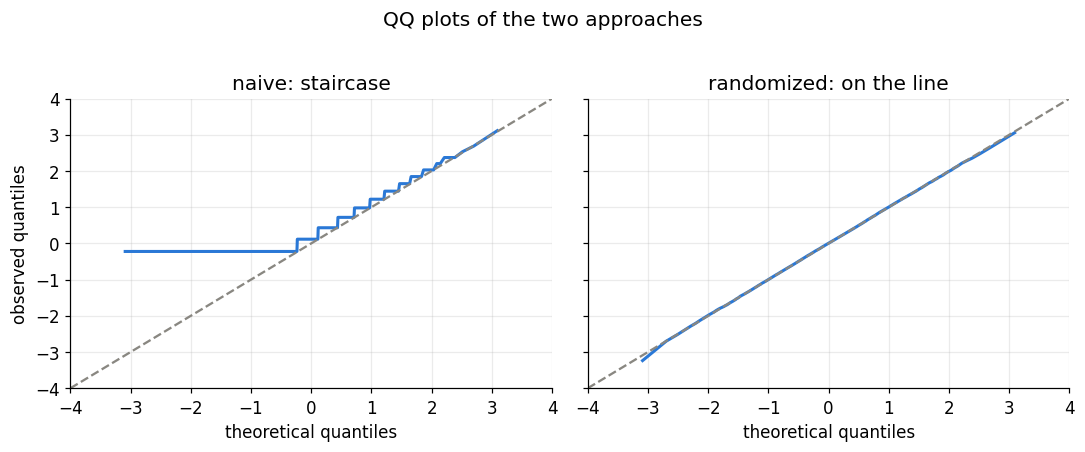

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, z, ttl in [(axes[0], z_naive, "naive: staircase"),
                   (axes[1], z_rqr, "randomized: on the line")]:
    q = np.linspace(0.001, 0.999, 400)
    ax.plot(norm.ppf(q), np.quantile(z, q), color=C_DATA, lw=2)
    ax.plot([-4, 4], [-4, 4], color=C_MUTE, ls="--", lw=1.5)
    ax.set(title=ttl, xlabel="theoretical quantiles", xlim=(-4, 4), ylim=(-4, 4))
axes[0].set_ylabel("observed quantiles")
fig.suptitle("QQ plots of the two approaches", y=1.02)
plt.tight_layout()
plt.show()

## 5. Going backwards: `backward` and centiles

Above $F(0)$ we need to undo the mixture (=go from Z -> Y). 
So for y>0:
$U = (1-\psi) + \psi\,F_{\text{NB}}(y)$ and solving for $F_{\text{NB}}(y)$:

$$F_{\text{NB}}(y) = \frac{U - (1-\psi)}{\psi}
\qquad\Longrightarrow\qquad
y = F_{\text{NB}}^{-1}\!\left(\frac{U - (1-\psi)}{\psi}\right)$$

$F_{\text{NB}}^{-1}$ is `nbinom.ppf`.

Note `backward` is **deterministic** — the randomness lives only in `forward`. So
individual z-scores wobble slightly between calls, but **centiles do not**.

### Reference

Dunn, P. K., & Smyth, G. K. (1996). Randomized quantile residuals.
*Journal of Computational and Graphical Statistics*, 5(3), 236–244.